In [19]:
import os

data_path = "../data/raw/kaggle_data"

print(os.listdir(data_path))

['CategoryCode_Mapping.xlsx', 'no_pii_action_history.json', 'no_pii_grievance.json']


In [20]:
import json

file_path = "../data/raw/kaggle_data/no_pii_grievance.json"

with open(file_path, "r", encoding="utf-8") as f:
    first_line = f.readline()

print(first_line[:2000])

[{



In [21]:
import json

file_path = "../data/raw/kaggle_data/no_pii_grievance.json"

with open(file_path, "r", encoding="utf-8") as f:
    content = f.read(100000)

decoder = json.JSONDecoder()

# Find the first actual JSON object
start = content.find("{")

record, end = decoder.raw_decode(content[start:])

print("First grievance record:")
print(record)

First grievance record:
{'_id': 'MORLY/E/2023/0000001', 'CategoryV7': 11578, 'DiaryDate': {'$date': '2023-01-01T00:00:19.977Z'}, 'UserCode': '110124', 'closing_date': {'$date': '2023-01-04T00:00:00Z'}, 'dist_name': 'North 24 Parganas', 'org_code': 'MORLY', 'pincode': '700130', 'recvd_date': {'$date': '2023-01-01T00:00:19.977Z'}, 'registration_no': 'MORLY/E/2023/0000001', 'remarks_text': '  As per railway record,  there is no authorized crossing in the said location. It is unsafe for both public and passengers to cross track  unauthorizedly. Because of unauthorized crossings track conditions are disturbed.', 'resolution_date': {'$date': '2023-01-04T00:00:00Z'}, 'sex': 'M', 'state': 'WB', 'subject_content_text': 'Railways, ( Railway Board) >> Miscellaneous\r\n\r\nRailway Board/ Zone/ PSU/ PU/ Office : Railway Board - Railway Board\r\n-----------------------\r\nTo\r\nThe Railway Board\r\nSDAH  ER\r\n\r\nLocation   Madhyamgram\r\n\r\nI  further to informing you that the temporary railway l

In [22]:
import pandas as pd

mapping_path = "../data/raw/kaggle_data/CategoryCode_Mapping.xlsx"

mapping = pd.read_excel(mapping_path)

print(mapping.shape)
print(mapping.columns.tolist())

(19853, 6)
['Code', 'Description', 'OrgCode', 'Parent', 'Stage', 'MonitoringCode']


In [23]:
import sys

print(sys.executable)

c:\Users\shiva\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [24]:
import sys

print(sys.executable)

c:\Users\shiva\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [25]:
mapping.head(10)

,Code,Description,OrgCode,Parent,Stage,MonitoringCode
0,1,Telecommunications,DOTEL,NaN,1,506.0
1,2,Mobile Related,DOTEL,1.0,2,506.0
2,3,Pension Related,DOTEL,1.0,2,102.0
3,4,Broadband Related,DOTEL,1.0,2,506.0
4,5,Landline Related,DOTEL,1.0,2,506.0
5,6,Employee Related / Services Related,DOTEL,1.0,2,101.0
6,7,Tower Related,DOTEL,1.0,2,506.0
7,8,Malpractices / Corruption / Complaint Related ...,DOTEL,1.0,2,301.0
8,9,Suggestions,DOTEL,1.0,2,2101.0
9,10,Others,DOTEL,1.0,2,1799.0


In [26]:
category_info = mapping[mapping["Code"] == 11578]

category_info

,Code,Description,OrgCode,Parent,Stage,MonitoringCode
9312,11578,Miscellaneous,MORLY,2565.0,2,2099.0


In [27]:
import ijson

file_path = "../data/raw/kaggle_data/no_pii_grievance.json"

count = 0

with open(file_path, "rb") as f:
    for _ in ijson.items(f, "item"):
        count += 1

print("Total grievance records:", count)

Total grievance records: 175784


In [28]:
import ijson
import pandas as pd
import os

file_path = "../data/raw/kaggle_data/no_pii_grievance.json"

records = []

fields = [
    "registration_no",
    "subject_content_text",
    "remarks_text",
    "CategoryV7",
    "org_code",
    "state",
    "dist_name",
    "pincode",
    "DiaryDate",
    "resolution_date",
    "closing_date",
    "v7_target"
]

with open(file_path, "rb") as f:
    for record in ijson.items(f, "item"):
        records.append({field: record.get(field) for field in fields})

df = pd.DataFrame(records)

print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Rows: 175784
Columns: 12


,registration_no,subject_content_text,remarks_text,CategoryV7,org_code,state,dist_name,pincode,DiaryDate,resolution_date,closing_date,v7_target
0,MORLY/E/2023/0000001,"Railways, ( Railway Board) >> Miscellaneous\r\...","As per railway record, there is no authoriz...",11578.0,MORLY,WB,North 24 Parganas,700130,{'$date': '2023-01-01T00:00:19.977Z'},{'$date': '2023-01-04T00:00:00Z'},{'$date': '2023-01-04T00:00:00Z'},No
1,GOVUP/E/2023/0000001,XAXPX/X/X0X2X4X0X0\tREGARDING CBCID INSPECTION...,NaN,NaN,GOVUP,UP,NaN,203001,{'$date': '2023-01-01T00:01:29.78Z'},None,{'$date': '2023-01-24T00:00:00Z'},NaN
2,MOLBR/E/2023/0000001,Labour and Employment >> PF Withdrawal >> Othe...,"Sir/Madam, With reference to Grievance no. XO...",2369.0,MOLBR,TG,Hyderabad,500023,{'$date': '2023-01-01T00:01:45.593Z'},{'$date': '2023-01-12T00:00:00Z'},{'$date': '2023-01-12T00:00:00Z'},No
3,MOLBR/E/2023/0000002,Labour and Employment >> Pension >> Others\r\n...,Please submit establishment clarification let...,2379.0,MOLBR,MH,Nagpur,440001,{'$date': '2023-01-01T00:02:07.247Z'},{'$date': '2023-01-06T00:00:00Z'},{'$date': '2023-01-06T00:00:00Z'},No
4,GOVUP/E/2023/0000002,XAXPX/X/X0X2X4X0X8\tREGARDING CBCID INSPECTION...,NaN,NaN,GOVUP,UP,NaN,203001,{'$date': '2023-01-01T00:02:25.663Z'},None,{'$date': '2023-01-24T00:00:00Z'},NaN


In [29]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate registration numbers:")
print(df["registration_no"].duplicated().sum())

print("\nUnique organizations:")
print(df["org_code"].nunique())

print("\nUnique category codes:")
print(df["CategoryV7"].nunique())

Missing values:
registration_no              0
subject_content_text         0
remarks_text             68880
CategoryV7              112162
org_code                   383
state                      263
dist_name                52976
pincode                  14282
DiaryDate                    0
resolution_date          68880
closing_date             13419
v7_target               119121
dtype: int64

Duplicate registration numbers:
0

Unique organizations:
200

Unique category codes:
3038


In [30]:
print("Empty complaint texts:")
print((df["subject_content_text"].fillna("").str.strip() == "").sum())

print("\nAverage complaint length:")
print(df["subject_content_text"].fillna("").str.len().mean())

print("\nShortest complaint length:")
print(df["subject_content_text"].fillna("").str.len().min())

print("\nLongest complaint length:")
print(df["subject_content_text"].fillna("").str.len().max())

Empty complaint texts:
2

Average complaint length:
843.4378043507942

Shortest complaint length:
1

Longest complaint length:
7292


In [31]:
df["subject_content_text"].fillna("").str.len().describe()

count    175784.000000
mean        843.437804
std         909.643354
min           1.000000
25%         183.000000
50%         539.000000
75%        1223.000000
max        7292.000000
Name: subject_content_text, dtype: float64

In [32]:
output_path = "../data/grievances_clean.csv"

clean_df.to_csv(output_path, index=False)

print("Clean dataset saved successfully!")
print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))
print("Location:", output_path)

NameError: name 'clean_df' is not defined

In [ ]:
import pandas as pd
import numpy as np

# Load the working dataset we already created
df = pd.read_csv("../data/grievances_working.csv")

print("Rows:", len(df))
print("Columns:", len(df.columns))

FileNotFoundError: [Errno 2] No such file or directory: '../data/grievances_working.csv'

In [ ]:
import ijson
import pandas as pd

file_path = "../data/raw/kaggle_data/no_pii_grievance.json"

fields = [
    "registration_no",
    "subject_content_text",
    "remarks_text",
    "CategoryV7",
    "org_code",
    "state",
    "dist_name",
    "pincode",
    "DiaryDate",
    "resolution_date",
    "closing_date",
    "v7_target"
]

records = []

with open(file_path, "rb") as f:
    for record in ijson.items(f, "item"):
        records.append({
            field: record.get(field)
            for field in fields
        })

df = pd.DataFrame(records)

print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 175784
Columns: 12


In [ ]:
df.to_csv("../data/grievances_working.csv", index=False)

print("grievances_working.csv created successfully!")

grievances_working.csv created successfully!


In [ ]:
import pandas as pd

# Load our working dataset
df = pd.read_csv("../data/grievances_working.csv")

# Make a copy
clean_df = df.copy()

# Clean complaint text
clean_df["subject_content_text"] = (
    clean_df["subject_content_text"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Remove empty complaint texts
clean_df = clean_df[
    clean_df["subject_content_text"] != ""
].copy()

# Convert category code
clean_df["CategoryV7"] = pd.to_numeric(
    clean_df["CategoryV7"],
    errors="coerce"
).astype("Int64")

# Keep pincode as text
clean_df["pincode"] = clean_df["pincode"].astype("string")

# Convert dates
for column in ["DiaryDate", "resolution_date", "closing_date"]:
    clean_df[column] = pd.to_datetime(
        clean_df[column],
        errors="coerce",
        utc=True
    )

print("Original rows:", len(df))
print("Clean rows:", len(clean_df))
print("Removed rows:", len(df) - len(clean_df))

C:\Users\shiva\AppData\Local\Temp\ipykernel_20992\1368987869.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  clean_df[column] = pd.to_datetime(


Original rows: 175784
Clean rows: 175779
Removed rows: 5


C:\Users\shiva\AppData\Local\Temp\ipykernel_20992\1368987869.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  clean_df[column] = pd.to_datetime(
C:\Users\shiva\AppData\Local\Temp\ipykernel_20992\1368987869.py:33: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  clean_df[column] = pd.to_datetime(


In [ ]:
clean_df.to_csv(
    "../data/grievances_clean.csv",
    index=False
)

print("grievances_clean.csv created successfully!")
print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))

grievances_clean.csv created successfully!
Rows: 175779
Columns: 12


In [ ]:
import pandas as pd

clean_df = pd.read_csv("../data/grievances_clean.csv")

print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))
print("\nColumns:")
print(clean_df.columns.tolist())

Rows: 175779
Columns: 12

Columns:
['registration_no', 'subject_content_text', 'remarks_text', 'CategoryV7', 'org_code', 'state', 'dist_name', 'pincode', 'DiaryDate', 'resolution_date', 'closing_date', 'v7_target']


In [ ]:
print("Missing values in each column:")
print(clean_df.isnull().sum())

Missing values in each column:
registration_no              0
subject_content_text         0
remarks_text             68877
CategoryV7              112157
org_code                   383
state                      263
dist_name                52974
pincode                  14282
DiaryDate               175779
resolution_date         175779
closing_date            175779
v7_target               119116
dtype: int64


In [ ]:
print("Number of organizations:", clean_df["org_code"].nunique())

print("\nTop 10 organizations:")
print(clean_df["org_code"].value_counts().head(10))

Number of organizations: 200

Top 10 organizations:
org_code
PMOPG    49880
MOLBR    11471
DEABD    10392
GOVUP     8493
DEAID     7803
DOAAC     6501
CBODT     6323
DARPG     5597
GOVAS     4673
DOTEL     4623
Name: count, dtype: int64


In [ ]:
print("Number of states:", clean_df["state"].nunique())

print("\nTop 10 states:")
print(clean_df["state"].value_counts().head(10))

Number of states: 40

Top 10 states:
state
UP    39332
BH    16295
MH    15206
DH    12380
GJ     9891
WB     9305
MP     8386
RJ     7735
TN     6735
HY     6612
Name: count, dtype: int64


In [ ]:
print("Number of category codes:", clean_df["CategoryV7"].nunique())

print("\nTop 10 category codes:")
print(clean_df["CategoryV7"].value_counts().head(10))

Number of category codes: 3038

Top 10 category codes:
CategoryV7
22456.0    4417
2358.0     2864
4455.0     2672
25809.0    1536
74.0       1462
276.0      1258
11578.0    1006
4422.0      805
2365.0      796
266.0       775
Name: count, dtype: int64


In [ ]:
org_mapping = (
    mapping[["OrgCode"]]
    .dropna()
    .drop_duplicates()
    .sort_values("OrgCode")
)

print("Organizations in mapping:", len(org_mapping))
org_mapping.head(20)

Organizations in mapping: 92


,OrgCode
2728,00000
5908,ARNPG
17659,AYUSH
5921,CAGAO
4103,CBODT
4154,CBOEC
19274,DARPG
5905,DATOM
6799,DBIOT
9586,DCLTR


In [34]:
import pandas as pd

# Load the cleaned dataset
clean_df = pd.read_csv("../data/grievances_clean.csv")

# Load the category mapping
mapping = pd.read_excel(
    "../data/raw/kaggle_data/CategoryCode_Mapping.xlsx"
)

print("Clean dataset:", clean_df.shape)
print("Mapping:", mapping.shape)

Clean dataset: (175779, 12)
Mapping: (19853, 6)


In [35]:
top_orgs = clean_df["org_code"].value_counts().head(10).index

org_details = (
    mapping[mapping["OrgCode"].isin(top_orgs)]
    [["OrgCode", "Description", "Code"]]
    .drop_duplicates()
)

org_details.head(30)

,OrgCode,Description,Code
0,DOTEL,Telecommunications,1
1,DOTEL,Mobile Related,2
2,DOTEL,Pension Related,3
3,DOTEL,Broadband Related,4
4,DOTEL,Landline Related,5
5,DOTEL,Employee Related / Services Related,6
6,DOTEL,Tower Related,7
7,DOTEL,Malpractices / Corruption / Complaint Related ...,8
8,DOTEL,Suggestions,9
9,DOTEL,Others,10


In [36]:
import pandas as pd
import re
import ast

clean_df = pd.read_csv("../data/grievances_clean.csv")

print(clean_df.shape)

(175779, 12)


In [37]:
def extract_mongo_date(value):
    if pd.isna(value):
        return pd.NaT

    value = str(value)

    # Extract the date inside {'$date': '...'}
    match = re.search(r"\$date['\"]?\s*:\s*['\"]([^'\"]+)", value)

    if match:
        return pd.to_datetime(
            match.group(1),
            errors="coerce",
            utc=True
        )

    return pd.to_datetime(value, errors="coerce", utc=True)

In [38]:
for column in ["DiaryDate", "resolution_date", "closing_date"]:
    clean_df[column] = clean_df[column].apply(extract_mongo_date)

print(clean_df[[
    "DiaryDate",
    "resolution_date",
    "closing_date"
]].head())

  DiaryDate resolution_date closing_date
0       NaT             NaT          NaT
1       NaT             NaT          NaT
2       NaT             NaT          NaT
3       NaT             NaT          NaT
4       NaT             NaT          NaT


In [39]:
print(clean_df[[
    "DiaryDate",
    "resolution_date",
    "closing_date"
]].isna().sum())

DiaryDate          175779
resolution_date    175779
closing_date       175779
dtype: int64


In [40]:
print(clean_df[[
    "DiaryDate",
    "resolution_date",
    "closing_date"
]].isna().sum())

DiaryDate          175779
resolution_date    175779
closing_date       175779
dtype: int64


In [41]:
print("DiaryDate raw value:")
print(date_records[0]["DiaryDate"])

print("\nType:")
print(type(date_records[0]["DiaryDate"]))

print("\nFull first record:")
print(date_records[0])

DiaryDate raw value:


NameError: name 'date_records' is not defined

In [42]:
import ijson
import pandas as pd

json_path = "../data/raw/kaggle_data/no_pii_grievance.json"

date_records = []

with open(json_path, "rb") as f:
    for record in ijson.items(f, "item"):
        date_records.append({
            "registration_no": record.get("registration_no"),
            "DiaryDate": record.get("DiaryDate"),
            "resolution_date": record.get("resolution_date"),
            "closing_date": record.get("closing_date")
        })

dates_df = pd.DataFrame(date_records)

print("Number of records:", len(dates_df))
print("\nFirst DiaryDate:")
print(dates_df.loc[0, "DiaryDate"])

print("\nType:")
print(type(dates_df.loc[0, "DiaryDate"]))

Number of records: 175784

First DiaryDate:
{'$date': '2023-01-01T00:00:19.977Z'}

Type:
<class 'dict'>


In [43]:
for column in ["DiaryDate", "resolution_date", "closing_date"]:
    dates_df[column] = dates_df[column].apply(
        lambda x: x.get("$date") if isinstance(x, dict) else None
    )

print(dates_df.head())

        registration_no                 DiaryDate       resolution_date  \
0  MORLY/E/2023/0000001  2023-01-01T00:00:19.977Z  2023-01-04T00:00:00Z   
1  GOVUP/E/2023/0000001   2023-01-01T00:01:29.78Z                   NaN   
2  MOLBR/E/2023/0000001  2023-01-01T00:01:45.593Z  2023-01-12T00:00:00Z   
3  MOLBR/E/2023/0000002  2023-01-01T00:02:07.247Z  2023-01-06T00:00:00Z   
4  GOVUP/E/2023/0000002  2023-01-01T00:02:25.663Z                   NaN   

           closing_date  
0  2023-01-04T00:00:00Z  
1  2023-01-24T00:00:00Z  
2  2023-01-12T00:00:00Z  
3  2023-01-06T00:00:00Z  
4  2023-01-24T00:00:00Z  


In [44]:
for column in ["DiaryDate", "resolution_date", "closing_date"]:
    dates_df[column] = pd.to_datetime(
        dates_df[column],
        errors="coerce",
        utc=True
    )

print(dates_df[
    ["DiaryDate", "resolution_date", "closing_date"]
].head())

                         DiaryDate           resolution_date  \
0 2023-01-01 00:00:19.977000+00:00 2023-01-04 00:00:00+00:00   
1 2023-01-01 00:01:29.780000+00:00                       NaT   
2 2023-01-01 00:01:45.593000+00:00 2023-01-12 00:00:00+00:00   
3 2023-01-01 00:02:07.247000+00:00 2023-01-06 00:00:00+00:00   
4 2023-01-01 00:02:25.663000+00:00                       NaT   

               closing_date  
0 2023-01-04 00:00:00+00:00  
1 2023-01-24 00:00:00+00:00  
2 2023-01-12 00:00:00+00:00  
3 2023-01-06 00:00:00+00:00  
4 2023-01-24 00:00:00+00:00  


In [45]:
print(
    dates_df[
        ["DiaryDate", "resolution_date", "closing_date"]
    ].isna().sum()
)

DiaryDate           2126
resolution_date    68880
closing_date       13756
dtype: int64


In [46]:
clean_df = pd.read_csv("../data/grievances_clean.csv")

print("Clean dataset:", clean_df.shape)

Clean dataset: (175779, 12)


In [47]:
clean_df = clean_df.drop(
    columns=["DiaryDate", "resolution_date", "closing_date"],
    errors="ignore"
)

In [48]:
clean_df = clean_df.merge(
    dates_df[
        [
            "registration_no",
            "DiaryDate",
            "resolution_date",
            "closing_date"
        ]
    ],
    on="registration_no",
    how="left"
)

print(clean_df.shape)
print(
    clean_df[
        ["DiaryDate", "resolution_date", "closing_date"]
    ].isna().sum()
)


(175779, 12)
DiaryDate           2126
resolution_date    68877
closing_date       13756
dtype: int64


In [49]:
clean_df["resolution_days"] = (
    clean_df["resolution_date"] - clean_df["DiaryDate"]
).dt.total_seconds() / (24 * 60 * 60)

print(clean_df["resolution_days"].describe())

count    106446.000000
mean         22.820279
std          31.410389
min         -20.084084
25%           3.471827
50%          12.009248
75%          28.392752
max         192.051941
Name: resolution_days, dtype: float64


In [50]:
# Identify logically invalid resolution times
invalid_resolution = clean_df["resolution_days"] < 0

print("Invalid negative resolution times:", invalid_resolution.sum())

# Set invalid values to missing
clean_df.loc[invalid_resolution, "resolution_days"] = pd.NA

print("\nCorrected resolution statistics:")
print(clean_df["resolution_days"].describe())

Invalid negative resolution times: 4799

Corrected resolution statistics:
count    101647.000000
mean         23.968428
std          31.678899
min           0.000020
25%           4.419923
50%          12.884123
75%          29.369979
max         192.051941
Name: resolution_days, dtype: float64


In [51]:
print("Valid resolution records:",
      clean_df["resolution_days"].notna().sum())

Valid resolution records: 101647


In [ ]:
clean_df.to_csv(
    "../data/grievances_clean.csv",
    index=False
)

print("Final cleaned dataset saved successfully!")
print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))

Final cleaned dataset saved successfully!
Rows: 175779
Columns: 13


In [1]:
import pandas as pd

clean_df = pd.read_csv("../data/grievances_clean.csv")

print("Dataset shape:", clean_df.shape)
print("\nColumns:")
print(clean_df.columns.tolist())

Dataset shape: (175779, 13)

Columns:
['registration_no', 'subject_content_text', 'remarks_text', 'CategoryV7', 'org_code', 'state', 'dist_name', 'pincode', 'v7_target', 'DiaryDate', 'resolution_date', 'closing_date', 'resolution_days']


In [2]:
org_counts = clean_df["org_code"].value_counts()

print("Total organizations:", clean_df["org_code"].nunique())

print("\nTop 15 organizations:")
print(org_counts.head(15))

Total organizations: 200

Top 15 organizations:
org_code
PMOPG    49880
MOLBR    11471
DEABD    10392
GOVUP     8493
DEAID     7803
DOAAC     6501
CBODT     6323
DARPG     5597
GOVAS     4673
DOTEL     4623
DPOST     4559
DOPPW     4414
MORLY     3069
MINHA     3037
GOVGJ     2209
Name: count, dtype: int64


In [3]:
org_percentage = (
    clean_df["org_code"]
    .value_counts(normalize=True)
    .head(15)
    .mul(100)
    .round(2)
)

print(org_percentage)

org_code
PMOPG    28.44
MOLBR     6.54
DEABD     5.92
GOVUP     4.84
DEAID     4.45
DOAAC     3.71
CBODT     3.60
DARPG     3.19
GOVAS     2.66
DOTEL     2.64
DPOST     2.60
DOPPW     2.52
MORLY     1.75
MINHA     1.73
GOVGJ     1.26
Name: proportion, dtype: float64


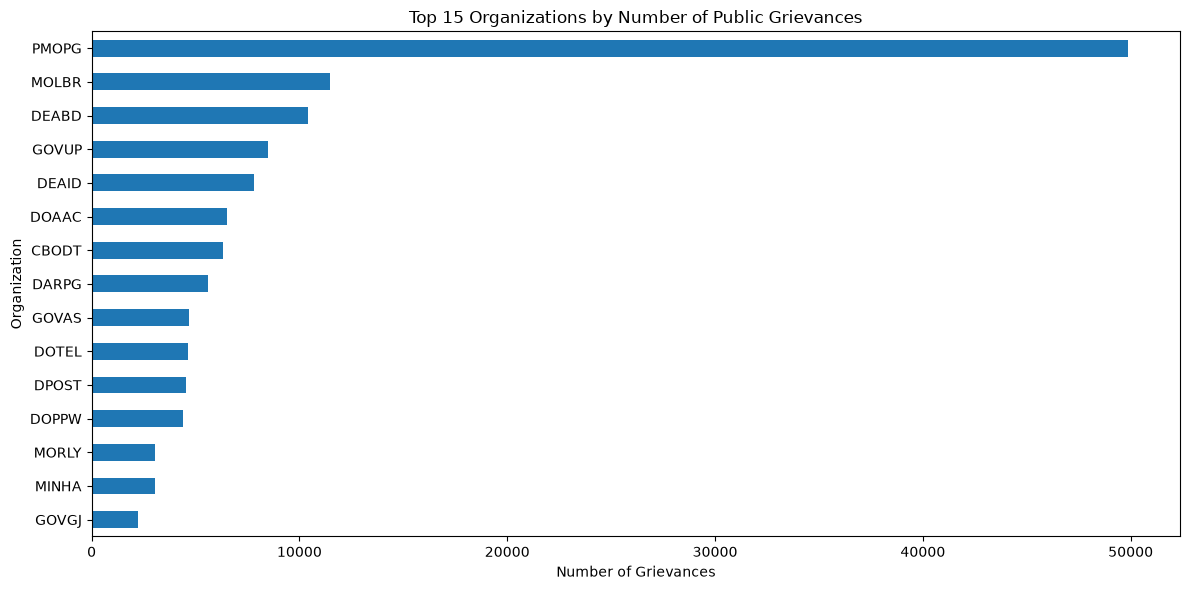

In [4]:
import matplotlib.pyplot as plt

top_orgs = clean_df["org_code"].value_counts().head(15)

plt.figure(figsize=(12, 6))

top_orgs.sort_values().plot(kind="barh")

plt.title("Top 15 Organizations by Number of Public Grievances")
plt.xlabel("Number of Grievances")
plt.ylabel("Organization")
plt.tight_layout()

plt.show()

In [5]:
state_counts = clean_df["state"].value_counts()

print("Total state/region codes:", clean_df["state"].nunique())

print("\nTop 15 states/regions:")
print(state_counts.head(15))

Total state/region codes: 40

Top 15 states/regions:
state
UP    39332
BH    16295
MH    15206
DH    12380
GJ     9891
WB     9305
MP     8386
RJ     7735
TN     6735
HY     6612
KN     6260
AS     6118
PB     4932
JH     3991
OR     3667
Name: count, dtype: int64


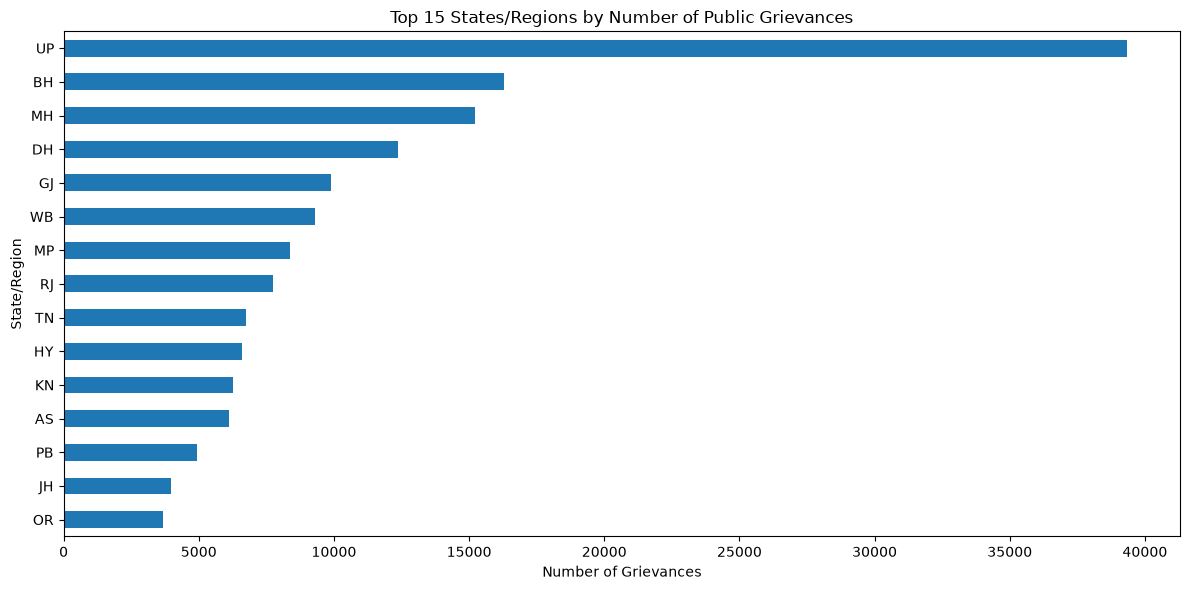

In [6]:
plt.figure(figsize=(12, 6))

state_counts.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 States/Regions by Number of Public Grievances")
plt.xlabel("Number of Grievances")
plt.ylabel("State/Region")
plt.tight_layout()

plt.show()

In [7]:
category_missing = clean_df["CategoryV7"].isna().sum()
category_present = clean_df["CategoryV7"].notna().sum()

print("Category available:", category_present)
print("Category missing:", category_missing)

print(
    "Category coverage:",
    round(category_present / len(clean_df) * 100, 2),
    "%"
)

Category available: 63622
Category missing: 112157
Category coverage: 36.19 %


In [8]:
category_counts = clean_df["CategoryV7"].value_counts()

print("Unique category codes:", clean_df["CategoryV7"].nunique())

print("\nTop 15 categories:")
print(category_counts.head(15))

Unique category codes: 3038

Top 15 categories:
CategoryV7
22456.0    4417
2358.0     2864
4455.0     2672
25809.0    1536
74.0       1462
276.0      1258
11578.0    1006
4422.0      805
2365.0      796
266.0       775
20697.0     771
2359.0      741
22449.0     740
263.0       683
25810.0     649
Name: count, dtype: int64


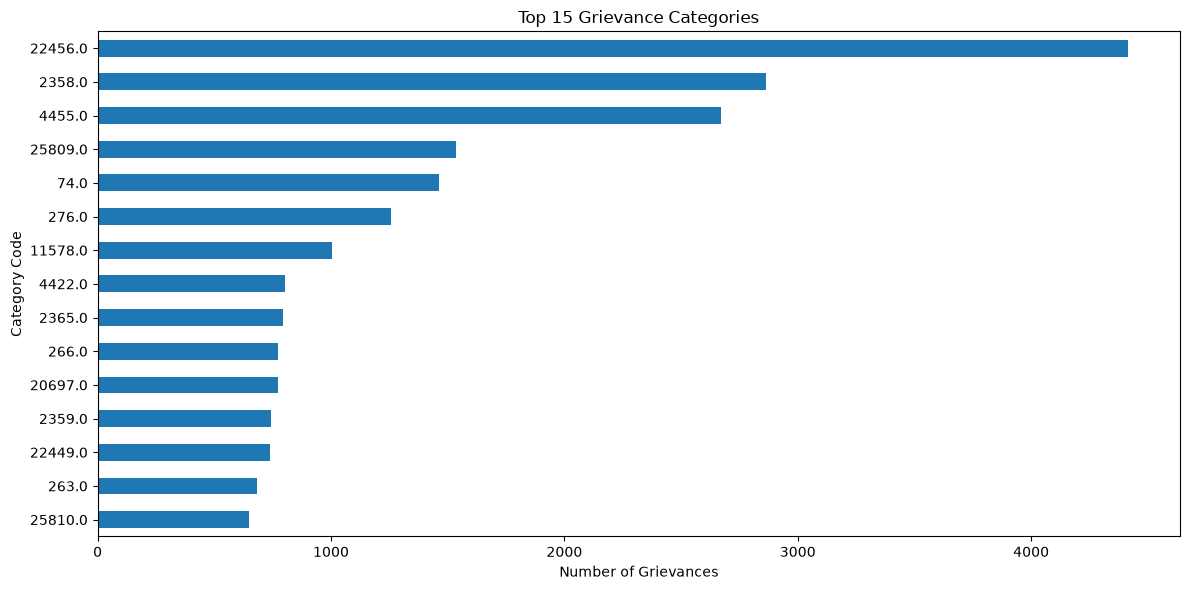

In [9]:
plt.figure(figsize=(12, 6))

category_counts.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Grievance Categories")
plt.xlabel("Number of Grievances")
plt.ylabel("Category Code")

plt.tight_layout()
plt.show()

In [11]:
# Get the top 15 category codes
top_categories = (
    clean_df["CategoryV7"]
    .dropna()
    .value_counts()
    .head(15)
    .reset_index()
)

top_categories.columns = ["Code", "Grievance_Count"]

# Make the code types compatible
top_categories["Code"] = top_categories["Code"].astype(int)
mapping["Code"] = pd.to_numeric(mapping["Code"], errors="coerce")

# Match category codes with their descriptions
category_details = top_categories.merge(
    mapping[["Code", "Description", "OrgCode"]],
    on="Code",
    how="left"
)

category_details

NameError: name 'mapping' is not defined

In [12]:
import pandas as pd

mapping = pd.read_excel(
    "../data/raw/kaggle_data/CategoryCode_Mapping.xlsx"
)

print("Mapping shape:", mapping.shape)
print(mapping.head())

Mapping shape: (19853, 6)
   Code         Description OrgCode  Parent  Stage  MonitoringCode
0     1  Telecommunications   DOTEL     NaN      1           506.0
1     2      Mobile Related   DOTEL     1.0      2           506.0
2     3     Pension Related   DOTEL     1.0      2           102.0
3     4   Broadband Related   DOTEL     1.0      2           506.0
4     5    Landline Related   DOTEL     1.0      2           506.0


In [13]:
top_categories = (
    clean_df["CategoryV7"]
    .dropna()
    .value_counts()
    .head(15)
    .reset_index()
)

top_categories.columns = ["Code", "Grievance_Count"]

top_categories["Code"] = top_categories["Code"].astype(int)

mapping["Code"] = pd.to_numeric(
    mapping["Code"],
    errors="coerce"
)

category_details = top_categories.merge(
    mapping[["Code", "Description", "OrgCode"]],
    on="Code",
    how="left"
)

category_details

,Code,Grievance_Count,Description,OrgCode
0,22456,4417,stoppage of installments after issue of few in...,DOAAC
1,2358,2864,Others (EPFO),MOLBR
2,4455,2672,"Refund matter, Wrong Demand",CBODT
3,25809,1536,Central Government related,DARPG
4,74,1462,Others/Misc.,DPOST
5,276,1258,Miscellaneous/Others,DEABD
6,11578,1006,Miscellaneous,MORLY
7,4422,805,Other/Misc/Suggestions,CBODT
8,2365,796,Correction of Member personal details,MOLBR
9,266,775,Misbehaviour/Harrassment/Corruption by Bank Staff,DEABD


In [14]:
print(
    category_details[
        ["Code", "Description", "OrgCode"]
    ].isna().sum()
)

Code           0
Description    0
OrgCode        0
dtype: int64


In [15]:
print("Overall Resolution Time Statistics:\n")

print(clean_df["resolution_days"].describe())

print("\nValid resolution records:")
print(clean_df["resolution_days"].notna().sum())

Overall Resolution Time Statistics:

count    101647.000000
mean         23.968428
std          31.678899
min           0.000020
25%           4.419923
50%          12.884123
75%          29.369979
max         192.051941
Name: resolution_days, dtype: float64

Valid resolution records:
101647


In [16]:
org_resolution = (
    clean_df
    .dropna(subset=["resolution_days", "org_code"])
    .groupby("org_code")
    .agg(
        grievances=("resolution_days", "count"),
        avg_resolution_days=("resolution_days", "mean"),
        median_resolution_days=("resolution_days", "median")
    )
)

# Keep organizations with at least 50 resolved grievances
org_resolution = org_resolution[
    org_resolution["grievances"] >= 50
]

# Sort by average resolution time
slowest_orgs = org_resolution.sort_values(
    "avg_resolution_days",
    ascending=False
)

print("Top 15 organizations with highest average resolution time:")
print(slowest_orgs.head(15))

Top 15 organizations with highest average resolution time:
          grievances  avg_resolution_days  median_resolution_days
org_code                                                         
CMASM            223            85.227468              102.415736
DOEAF             77            77.654646               57.264265
GOVMH            293            68.957207               59.321234
DOAAC           2020            55.723802               44.085956
DOLDR             75            53.482765               36.073063
DODWS             85            52.808593               35.405713
DORVU            151            50.145568               34.405724
DOPAT           1767            48.910055               39.657850
CBODT           5563            47.669777               32.527331
GOVGJ           1726            44.665099               27.048145
GOVHY            562            43.139341               27.672627
GOVJH            311            41.403475               25.266104
GOVTN            

In [17]:
fastest_orgs = org_resolution.sort_values(
    "avg_resolution_days",
    ascending=True
)

print("Top 15 organizations with lowest average resolution time:")
print(fastest_orgs.head(15))

Top 15 organizations with lowest average resolution time:
          grievances  avg_resolution_days  median_resolution_days
org_code                                                         
MOCOP            768             3.588231                2.177267
DOTEL           3217             5.287770                3.086853
DOEXP            572             5.753264                2.231982
DOFPD            265             5.834025                1.247658
MOLBR          10060             7.200394                5.209928
DEAPR            191             7.874027                2.404487
DDPRO            156             8.126875                1.183321
MEAPD            925             8.883170                3.237085
DCOYA            873             9.212235                4.508369
DEAID           7579             9.422588                9.013105
SCRLY             68            10.048776                6.573038
DODAF            110            11.456845                9.262035
DPOST           40

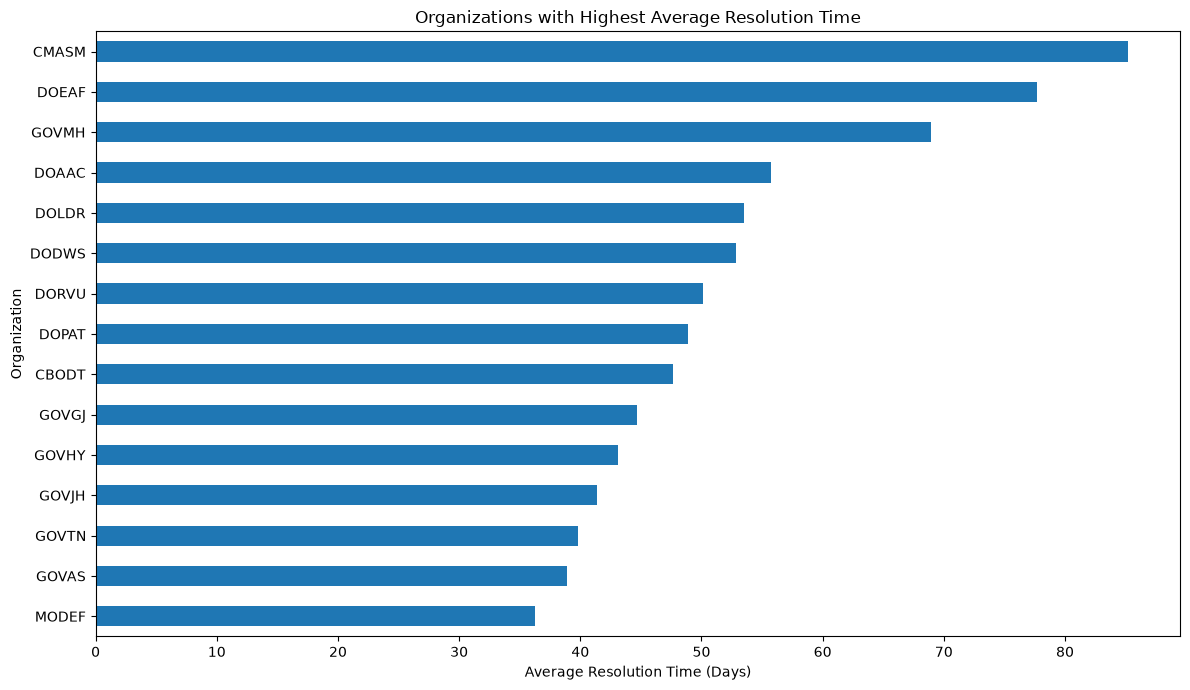

In [18]:
import matplotlib.pyplot as plt

slowest = (
    org_resolution
    .sort_values("avg_resolution_days", ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 7))

slowest["avg_resolution_days"].sort_values().plot(
    kind="barh"
)

plt.title("Organizations with Highest Average Resolution Time")
plt.xlabel("Average Resolution Time (Days)")
plt.ylabel("Organization")

plt.tight_layout()
plt.show()

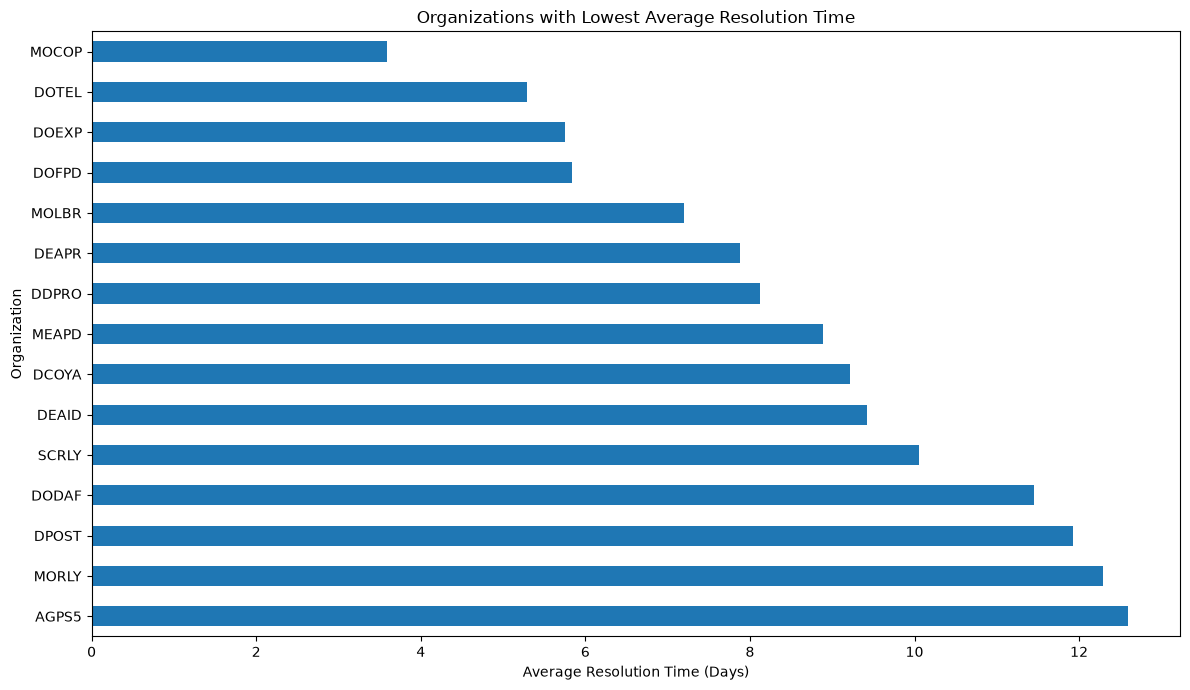

In [19]:
fastest = (
    org_resolution
    .sort_values("avg_resolution_days", ascending=True)
    .head(15)
)

plt.figure(figsize=(12, 7))

fastest["avg_resolution_days"].sort_values(ascending=False).plot(
    kind="barh"
)

plt.title("Organizations with Lowest Average Resolution Time")
plt.xlabel("Average Resolution Time (Days)")
plt.ylabel("Organization")

plt.tight_layout()
plt.show()

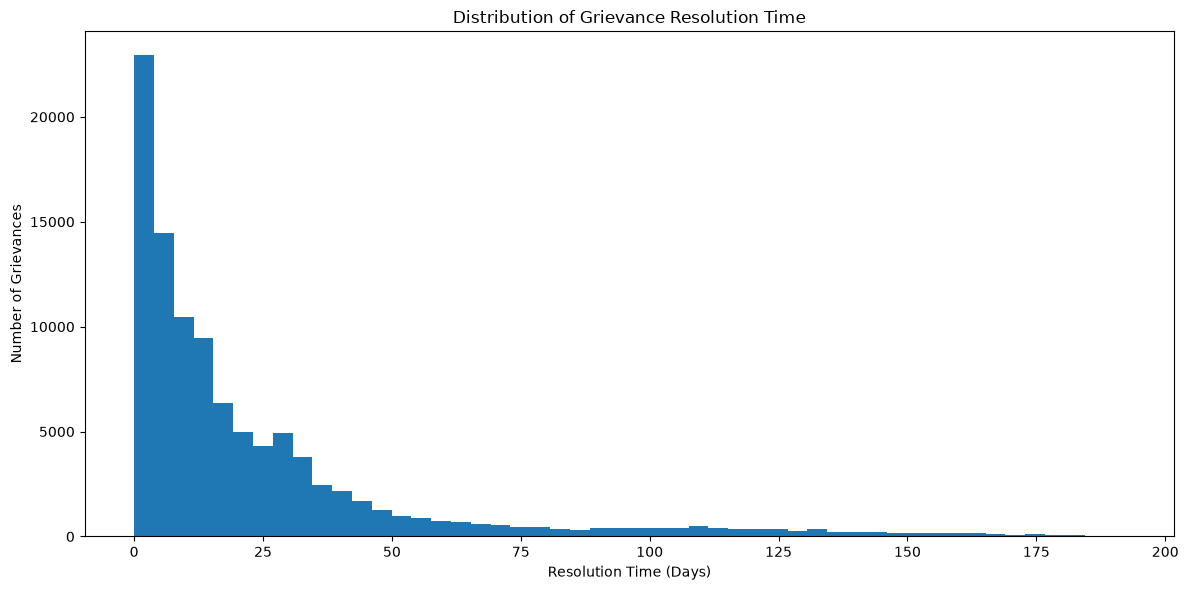

In [20]:
plt.figure(figsize=(12, 6))

clean_df["resolution_days"].dropna().plot(
    kind="hist",
    bins=50
)

plt.title("Distribution of Grievance Resolution Time")
plt.xlabel("Resolution Time (Days)")
plt.ylabel("Number of Grievances")

plt.tight_layout()
plt.show()

In [21]:
# Complaint text quality analysis

text_lengths = clean_df["subject_content_text"].fillna("").str.len()

print("Total complaints:", len(text_lengths))
print("Empty complaints:", (text_lengths == 0).sum())
print("Average length:", text_lengths.mean())
print("Median length:", text_lengths.median())
print("Shortest:", text_lengths.min())
print("Longest:", text_lengths.max())

Total complaints: 175779
Empty complaints: 0
Average length: 843.3129839173052
Median length: 539.0
Shortest: 1
Longest: 7292


In [22]:
# Show a few actual complaints

for i in range(5):
    print("=" * 80)
    print(clean_df.iloc[i]["subject_content_text"])

Railways, ( Railway Board) >> Miscellaneous

Railway Board/ Zone/ PSU/ PU/ Office : Railway Board - Railway Board
-----------------------
To
The Railway Board
SDAH  ER

Location   Madhyamgram

I  further to informing you that the temporary railway line crossing near Madhyamgram station  BT end.  is in a very bad condition. The stones on the side of the line have been moved far enough to cause great danger to the yrain,common people and train passengers at any time. Please look at the matter.  Although it was said that the place will be fixed but not done!
Thanking you
Yours truly
Bhaskar  Mitra
1.1.2023
XAXPX/X/X0X2X4X0X0	REGARDING CBCID INSPECTION,
closed on wrong facts, without investigate, evidence and blamed, abused to the complainant by ASP NAGAR BULANDSHAHR ANUKRITI SHARMA JI, Mr. T.P. Singh Superintending of Post H.P.O. Bulandshahr and Mr. Rajeev Umrao Postmaster General Agra. Please investigate attached pdf file matter and lodge a FIR in it. IN PRESENT THE COMPLAINANT WANTS MEN

In [23]:
# Prepare data for RAG

rag_df = clean_df.copy()

# Replace missing values
rag_df["remarks_text"] = rag_df["remarks_text"].fillna("")
rag_df["org_code"] = rag_df["org_code"].fillna("Unknown")
rag_df["state"] = rag_df["state"].fillna("Unknown")
rag_df["CategoryV7"] = rag_df["CategoryV7"].fillna("Unknown")

# Create category description from mapping
mapping["Code"] = pd.to_numeric(mapping["Code"], errors="coerce")

category_map = (
    mapping
    .drop_duplicates("Code")
    .set_index("Code")["Description"]
    .to_dict()
)

rag_df["category_description"] = (
    pd.to_numeric(rag_df["CategoryV7"], errors="coerce")
    .map(category_map)
    .fillna("Unknown")
)

print("RAG dataframe shape:", rag_df.shape)

rag_df[
    [
        "registration_no",
        "org_code",
        "state",
        "category_description",
        "subject_content_text",
        "remarks_text",
        "resolution_days"
    ]
].head(2)

RAG dataframe shape: (175779, 14)


,registration_no,org_code,state,category_description,subject_content_text,remarks_text,resolution_days
0,MORLY/E/2023/0000001,MORLY,WB,Miscellaneous,"Railways, ( Railway Board) >> Miscellaneous\r\...","As per railway record, there is no authoriz...",2.999769
1,GOVUP/E/2023/0000001,GOVUP,UP,Unknown,XAXPX/X/X0X2X4X0X0\tREGARDING CBCID INSPECTION...,,NaN


In [24]:
def create_rag_document(row):

    complaint = str(row["subject_content_text"]).strip()
    remarks = str(row["remarks_text"]).strip()

    document = f"""
Grievance Organization: {row["org_code"]}
State/Region: {row["state"]}
Category: {row["category_description"]}

Complaint:
{complaint}

Resolution/Official Remarks:
{remarks}
"""

    return document.strip()


rag_df["rag_document"] = rag_df.apply(
    create_rag_document,
    axis=1
)

print(rag_df["rag_document"].iloc[0])

Grievance Organization: MORLY
State/Region: WB
Category: Miscellaneous

Complaint:
Railways, ( Railway Board) >> Miscellaneous

Railway Board/ Zone/ PSU/ PU/ Office : Railway Board - Railway Board
-----------------------
To
The Railway Board
SDAH  ER

Location   Madhyamgram

I  further to informing you that the temporary railway line crossing near Madhyamgram station  BT end.  is in a very bad condition. The stones on the side of the line have been moved far enough to cause great danger to the yrain,common people and train passengers at any time. Please look at the matter.  Although it was said that the place will be fixed but not done!
Thanking you
Yours truly
Bhaskar  Mitra
1.1.2023

Resolution/Official Remarks:
As per railway record,  there is no authorized crossing in the said location. It is unsafe for both public and passengers to cross track  unauthorizedly. Because of unauthorized crossings track conditions are disturbed.


In [25]:
resolved_rag_df = rag_df[
    rag_df["resolution_days"].notna()
].copy()

print("Total RAG documents:", len(rag_df))
print("Resolved RAG documents:", len(resolved_rag_df))

Total RAG documents: 175779
Resolved RAG documents: 101647


In [26]:
import os

os.makedirs("../data/processed", exist_ok=True)

rag_df.to_csv(
    "../data/processed/rag_documents.csv",
    index=False
)

resolved_rag_df.to_csv(
    "../data/processed/resolved_rag_documents.csv",
    index=False
)

print("RAG datasets saved successfully.")

RAG datasets saved successfully.


In [28]:
import re

def mask_pii(text):
    text = str(text)

    # Mask email addresses
    text = re.sub(
        r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b',
        '[EMAIL]',
        text
    )

    # Mask Indian-style mobile numbers
    text = re.sub(
        r'\b(?:\+91[\s-]?)?[6-9]\d{9}\b',
        '[PHONE]',
        text
    )

    # Mask long numeric identifiers
    text = re.sub(
        r'\b\d{10,}\b',
        '[ID_NUMBER]',
        text
    )

    return text


rag_df["rag_document_masked"] = (
    rag_df["rag_document"].apply(mask_pii)
)

resolved_rag_df["rag_document_masked"] = (
    resolved_rag_df["rag_document"].apply(mask_pii)
)

print("PII masking completed.")

PII masking completed.


In [29]:
print(rag_df["rag_document_masked"].iloc[0])

Grievance Organization: MORLY
State/Region: WB
Category: Miscellaneous

Complaint:
Railways, ( Railway Board) >> Miscellaneous

Railway Board/ Zone/ PSU/ PU/ Office : Railway Board - Railway Board
-----------------------
To
The Railway Board
SDAH  ER

Location   Madhyamgram

I  further to informing you that the temporary railway line crossing near Madhyamgram station  BT end.  is in a very bad condition. The stones on the side of the line have been moved far enough to cause great danger to the yrain,common people and train passengers at any time. Please look at the matter.  Although it was said that the place will be fixed but not done!
Thanking you
Yours truly
Bhaskar  Mitra
1.1.2023

Resolution/Official Remarks:
As per railway record,  there is no authorized crossing in the said location. It is unsafe for both public and passengers to cross track  unauthorizedly. Because of unauthorized crossings track conditions are disturbed.


In [30]:
print(
    "Original length:",
    len(rag_df["rag_document"].iloc[0])
)

print(
    "Masked length:",
    len(rag_df["rag_document_masked"].iloc[0])
)

Original length: 957
Masked length: 957


In [31]:
import os

os.makedirs("../data/processed", exist_ok=True)

rag_df.to_csv(
    "../data/processed/rag_documents_masked.csv",
    index=False
)

resolved_rag_df.to_csv(
    "../data/processed/resolved_rag_documents_masked.csv",
    index=False
)

print("Masked RAG datasets saved successfully!")
print("All grievances:", len(rag_df))
print("Resolved grievances:", len(resolved_rag_df))

Masked RAG datasets saved successfully!
All grievances: 175779
Resolved grievances: 101647


In [32]:
def chunk_text(text, chunk_size=1000, overlap=150):
    text = str(text)

    if len(text) <= chunk_size:
        return [text]

    chunks = []
    start = 0

    while start < len(text):
        end = start + chunk_size
        chunk = text[start:end]

        chunks.append(chunk)

        start += chunk_size - overlap

    return chunks


# Test the function
test_text = rag_df["rag_document_masked"].iloc[0]

test_chunks = chunk_text(test_text)

print("Original length:", len(test_text))
print("Number of chunks:", len(test_chunks))

for i, chunk in enumerate(test_chunks):
    print("\n--- Chunk", i + 1, "---")
    print(chunk[:300])

Original length: 957
Number of chunks: 1

--- Chunk 1 ---
Grievance Organization: MORLY
State/Region: WB
Category: Miscellaneous

Complaint:
Railways, ( Railway Board) >> Miscellaneous

Railway Board/ Zone/ PSU/ PU/ Office : Railway Board - Railway Board
-----------------------
To
The Railway Board
SDAH  ER

Location   Madhyamgram

I  further to 


In [33]:
longest_text = rag_df["rag_document_masked"].loc[
    rag_df["rag_document_masked"].str.len().idxmax()
]

longest_chunks = chunk_text(longest_text)

print("Longest document length:", len(longest_text))
print("Number of chunks:", len(longest_chunks))

Longest document length: 7399
Number of chunks: 9


In [35]:
# Apply chunking to all grievance documents

rag_df["chunks"] = rag_df["rag_document_masked"].apply(
    chunk_text
)

print("Chunking completed!")

Chunking completed!


In [36]:
print("Total documents:", len(rag_df))

print(
    "Total chunks:",
    rag_df["chunks"].apply(len).sum()
)

print(
    "Average chunks per document:",
    rag_df["chunks"].apply(len).mean()
)

Total documents: 175779
Total chunks: 313391
Average chunks per document: 1.7828693985060786


In [37]:
chunk_records = []

for _, row in rag_df.iterrows():

    for chunk_number, chunk in enumerate(row["chunks"]):

        chunk_records.append({
            "registration_no": row["registration_no"],
            "org_code": row["org_code"],
            "state": row["state"],
            "category": row["category_description"],
            "resolution_days": row["resolution_days"],
            "chunk_id": chunk_number,
            "text": chunk
        })

print("Total chunk records:", len(chunk_records))

Total chunk records: 313391


In [38]:
chunks_df = pd.DataFrame(chunk_records)

print("Chunk dataset shape:", chunks_df.shape)

print(chunks_df.head())

Chunk dataset shape: (313391, 7)
        registration_no org_code state       category  resolution_days  \
0  MORLY/E/2023/0000001    MORLY    WB  Miscellaneous         2.999769   
1  GOVUP/E/2023/0000001    GOVUP    UP        Unknown              NaN   
2  GOVUP/E/2023/0000001    GOVUP    UP        Unknown              NaN   
3  GOVUP/E/2023/0000001    GOVUP    UP        Unknown              NaN   
4  MOLBR/E/2023/0000001    MOLBR    TG         Others        10.998778   

   chunk_id                                               text  
0         0  Grievance Organization: MORLY\nState/Region: W...  
1         0  Grievance Organization: GOVUP\nState/Region: U...  
2         1  FIR DATED 28.06.2022 AND ASP Bulandshahr Shri ...  
3         2  S MENTAL HARASSMENT XOXPXNXAXIXN AND A LEGAL A...  
4         0  Grievance Organization: MOLBR\nState/Region: T...  


In [ ]:
import os

os.makedirs("../data/processed", exist_ok=True)

chunks_df.to_csv(
    "../data/processed/grievance_chunks.csv",
    index=False
)

print("Chunk dataset saved successfully!")
print("Rows:", len(chunks_df))
print("Columns:", len(chunks_df.columns))

Chunk dataset saved successfully!
Rows: 313391
Columns: 7
